# Exploratory analysis

In [1]:
from pathlib import Path

from tabulate import tabulate
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

PROJECT_DIR = Path.cwd()
FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
TWITTER_FILE = PROJECT_DIR / "total.csv"
GDELT_ELECTION_FILE = PROJECT_DIR / "GDELT_US_election.csv"
GDELT_EVENTS_FILE = PROJECT_DIR / "GDELT_US_events.csv"
ANALYSIS_START = pd.Timestamp("2019-11-30")
PRETREATMENT_END = pd.Timestamp("2021-01-05")
ROLLOUT_START = pd.Timestamp("2021-01-06")
ROLLOUT_END = pd.Timestamp("2021-01-11")
POST_START = pd.Timestamp("2021-01-12")
ANALYSIS_END = pd.Timestamp("2021-05-06")
GDELT_COMPONENTS = 3
SEED = 42

ACTIVITY_DISRUPTIONS = pd.DataFrame([
    {"level": "ha", "start": "2020-08-16", "end": "2020-08-18"},
    {"level": "ha", "start": "2020-10-15", "end": "2020-10-15"},
    {"level": "la", "start": "2020-10-22", "end": "2020-11-03"},
    {"level": "ma", "start": "2020-10-24", "end": "2020-10-30"},
])

ACTIVITY_DISRUPTIONS[["start", "end"]] = ACTIVITY_DISRUPTIONS[["start", "end"]].apply(pd.to_datetime)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Data

## Coverage

In [2]:
twitter_raw = pd.read_csv(TWITTER_FILE, parse_dates=["date"])
gdelt_election = pd.read_csv(GDELT_ELECTION_FILE, parse_dates=["date"])
gdelt_events = pd.read_csv(GDELT_EVENTS_FILE, parse_dates=["date"])
twitter_observed = twitter_raw.loc[twitter_raw["stat"].astype(str).str.lower().eq("total") & twitter_raw["date"].between(ANALYSIS_START, ANALYSIS_END)].copy()
subset_metadata = twitter_observed[["subsets", "grouping", "level"]].drop_duplicates().sort_values("subsets").reset_index(drop=True)
subset_columns = subset_metadata["subsets"].tolist()
model_dates = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="D", name="date")
complete_index = pd.MultiIndex.from_product([model_dates, subset_columns], names=["date", "subsets"]).to_frame(index=False)
twitter_observed["source_row_present"] = True
panel = complete_index.merge(subset_metadata, on="subsets", validate="many_to_one").merge(twitter_observed.drop(columns=["grouping", "level"]), on=["date", "subsets"], how="left", validate="one_to_one").sort_values(["subsets", "date"]).reset_index(drop=True)
panel["source_row_present"] = panel["source_row_present"].eq(True)
panel["structural_zero"] = panel["grouping"].eq("suspended") & panel["date"].ge(POST_START) & ~panel["source_row_present"]
panel["disruption"] = False

for disruption in ACTIVITY_DISRUPTIONS.itertuples(index=False):
    panel.loc[panel["level"].eq(disruption.level) & panel["date"].between(disruption.start, disruption.end), "disruption"] = True

panel["ordinary_missing"] = ~panel["source_row_present"] & ~panel["structural_zero"] & ~panel["disruption"]
panel["total_output"] = pd.to_numeric(panel["fake_merged"], errors="coerce") + pd.to_numeric(panel["not_fake"], errors="coerce")
panel["misinformation_rate"] = pd.to_numeric(panel["fake_merged"], errors="coerce").div(pd.to_numeric(panel["n"], errors="coerce").replace(0, np.nan))

coverage = pd.DataFrame([
    {"source": "Twitter", "start": twitter_raw["date"].min(), "end": twitter_raw["date"].max(), "rows": len(twitter_raw), "columns": twitter_raw.shape[1], "missing_values": int(twitter_raw.isna().sum().sum())},
    {"source": "GDELT election", "start": gdelt_election["date"].min(), "end": gdelt_election["date"].max(), "rows": len(gdelt_election), "columns": gdelt_election.shape[1], "missing_values": int(gdelt_election.isna().sum().sum())},
    {"source": "GDELT events", "start": gdelt_events["date"].min(), "end": gdelt_events["date"].max(), "rows": len(gdelt_events), "columns": gdelt_events.shape[1], "missing_values": int(gdelt_events.isna().sum().sum())}])
print(tabulate(coverage, headers=coverage.columns, tablefmt='grid', showindex=False))

+----------------+---------------------+---------------------+--------+-----------+------------------+
| source         | start               | end                 |   rows |   columns |   missing_values |
+================+=====================+=====================+========+===========+==================+
| Twitter        | 2019-11-30 00:00:00 | 2021-05-31 00:00:00 |  15630 |        31 |             6433 |
+----------------+---------------------+---------------------+--------+-----------+------------------+
| GDELT election | 2019-11-30 00:00:00 | 2021-05-15 00:00:00 |    533 |        66 |              857 |
+----------------+---------------------+---------------------+--------+-----------+------------------+
| GDELT events   | 2019-11-30 00:00:00 | 2021-05-15 00:00:00 |    533 |        54 |               48 |
+----------------+---------------------+---------------------+--------+-----------+------------------+


In [3]:
status_summary = panel.assign(period=np.select([panel["date"].le(PRETREATMENT_END), panel["date"].between(ROLLOUT_START, ROLLOUT_END), panel["date"].ge(POST_START)], ["pretreatment", "rollout", "fully treated"], default="outside")).groupby(["period", "level"], observed=True).agg(rows=("date", "size"), source_rows=("source_row_present", "sum"), disruptions=("disruption", "sum"), structural_zeros=("structural_zero", "sum"), ordinary_missing=("ordinary_missing", "sum")).reset_index()
pre_counts = panel.loc[panel["date"].le(PRETREATMENT_END)].groupby("subsets")["date"].nunique()
balanced_before_treatment = bool(pre_counts.eq((PRETREATMENT_END - ANALYSIS_START).days + 1).all())
print("Balanced date-subset index before treatment:", balanced_before_treatment)
print(tabulate(status_summary, headers=status_summary.columns, tablefmt='grid', showindex=False))

Balanced date-subset index before treatment: True
+---------------+---------+--------+---------------+---------------+--------------------+--------------------+
| period        | level   |   rows |   source_rows |   disruptions |   structural_zeros |   ordinary_missing |
+===============+=========+========+===============+===============+====================+====================+
| fully treated | ha      |    575 |           460 |             0 |                115 |                  0 |
+---------------+---------+--------+---------------+---------------+--------------------+--------------------+
| fully treated | la      |    575 |           460 |             0 |                115 |                  0 |
+---------------+---------+--------+---------------+---------------+--------------------+--------------------+
| fully treated | ma      |    575 |           460 |             0 |                115 |                  0 |
+---------------+---------+--------+---------------+----------

In [4]:
scale_summary = panel.loc[panel["date"].le(PRETREATMENT_END) & ~panel["disruption"]].groupby(["grouping", "level"], observed=True)[["n", "nusers", "fake_merged"]].agg(["median", "mean", "max"])

for l in ["ha", "ma", "la"]:
    t = scale_summary.loc[scale_summary.index.get_level_values("level")==l].reset_index(drop=False)
    t.columns = ["_".join(map(str, c)) if isinstance(c, tuple) else str(c) for c in t.columns]
    t = t.T
    t = t.loc[t.index.get_level_values(0) != "level_"]
    print(tabulate(t, tablefmt='grid', showindex=True))
    print("\n\n")

+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
| grouping_          | A                 | D                  | F                  | nfns               | suspended          |
+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
| n_median           | 2081.0            | 32912.0            | 16647.0            | 14618.0            | 5421.0             |
+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
| n_mean             | 2091.814536340852 | 32030.659147869676 | 16532.56140350877  | 14434.872180451128 | 5086.062656641604  |
+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
| n_max              | 4024.0            | 45121.0            | 29200.0            | 21446.0            | 8964.

# Pretreatment structure

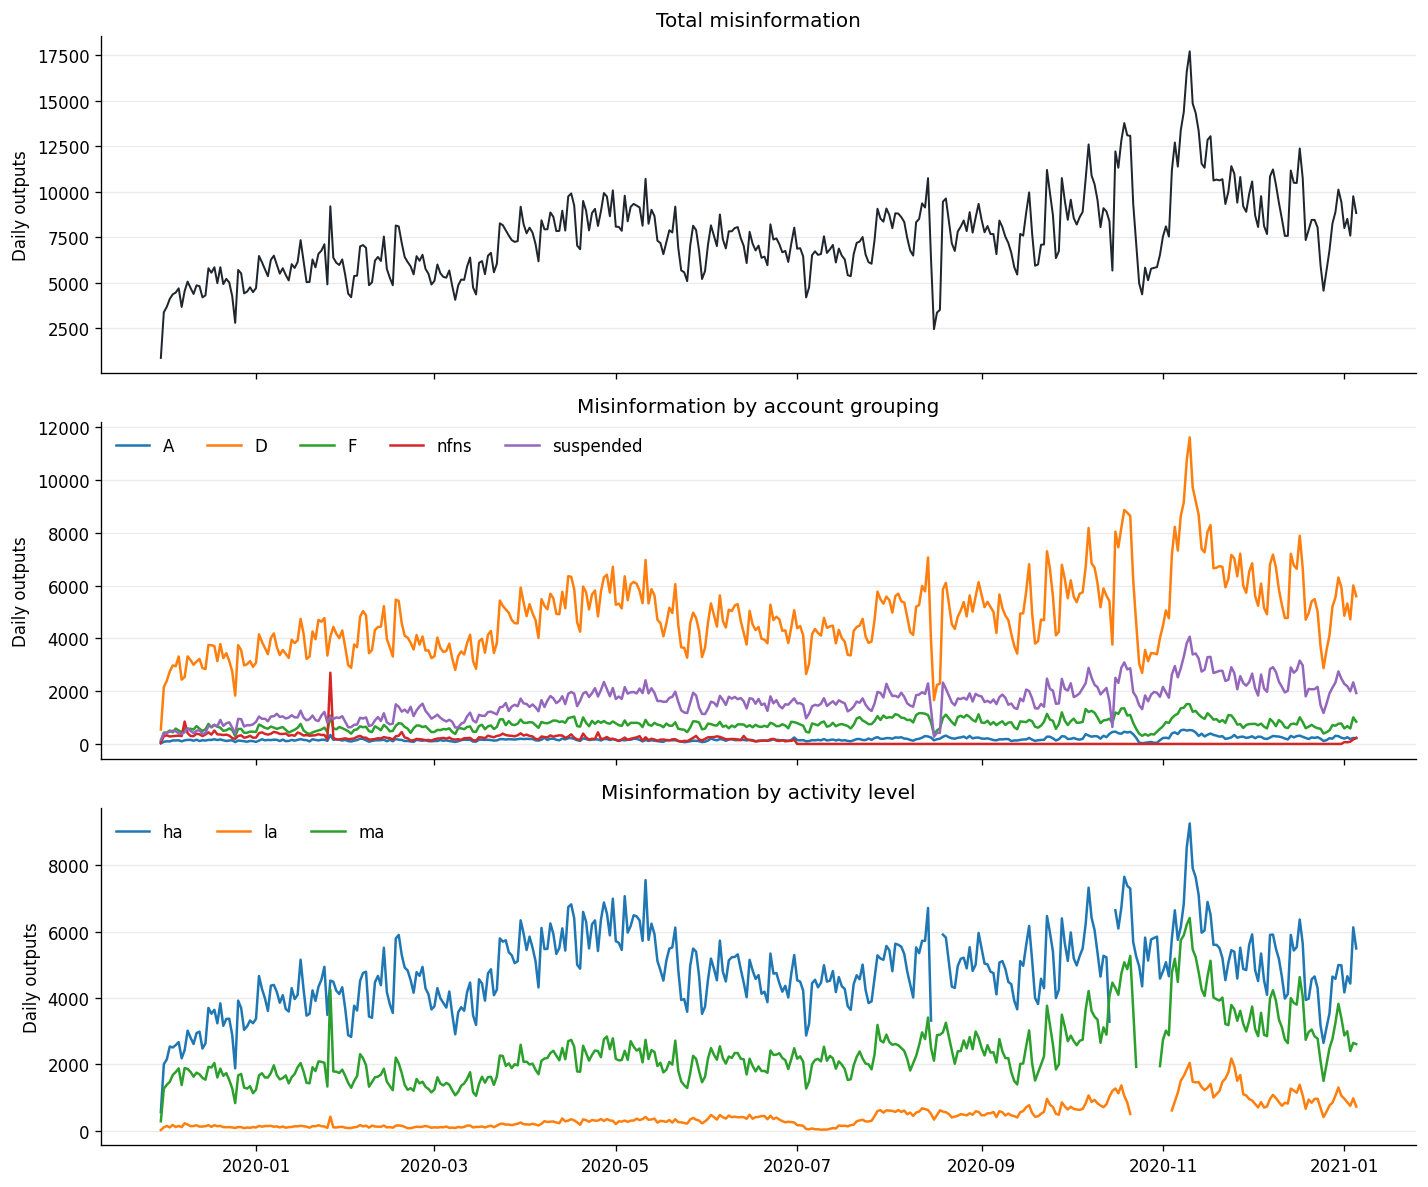

In [5]:
def cleaned_wide(column):
    values = pd.to_numeric(panel[column], errors="coerce").copy()
    values.loc[panel["structural_zero"]] = 0
    values.loc[panel["disruption"]] = np.nan
    frame = panel[["date", "subsets"]].copy()
    frame["value"] = values
    return frame.pivot(index="date", columns="subsets", values="value").reindex(model_dates).reindex(columns=subset_columns)

misinformation = cleaned_wide("fake_merged")
activity = cleaned_wide("n")
active_users = cleaned_wide("nusers")
pre_misinformation = misinformation.loc[:PRETREATMENT_END]
pre_activity = activity.loc[:PRETREATMENT_END]
pre_users = active_users.loc[:PRETREATMENT_END]
group_columns = {name: part["subsets"].tolist() for name, part in subset_metadata.groupby("grouping")}
level_columns = {name: part["subsets"].tolist() for name, part in subset_metadata.groupby("level")}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(pre_misinformation.sum(axis=1, min_count=1), color="#20262e", linewidth=1.2)
for name, columns in group_columns.items():
    axes[1].plot(pre_misinformation[columns].sum(axis=1, min_count=1), label=name)
for name, columns in level_columns.items():
    axes[2].plot(pre_misinformation[columns].sum(axis=1, min_count=1), label=name)
axes[0].set_title("Total misinformation")
axes[1].set_title("Misinformation by account grouping")
axes[2].set_title("Misinformation by activity level")
for axis in axes:
    axis.set_ylabel("Daily outputs")
    axis.grid(axis="y", alpha=.25)
axes[1].legend(ncol=5, frameon=False)
axes[2].legend(ncol=3, frameon=False)
fig.tight_layout()
plt.show()

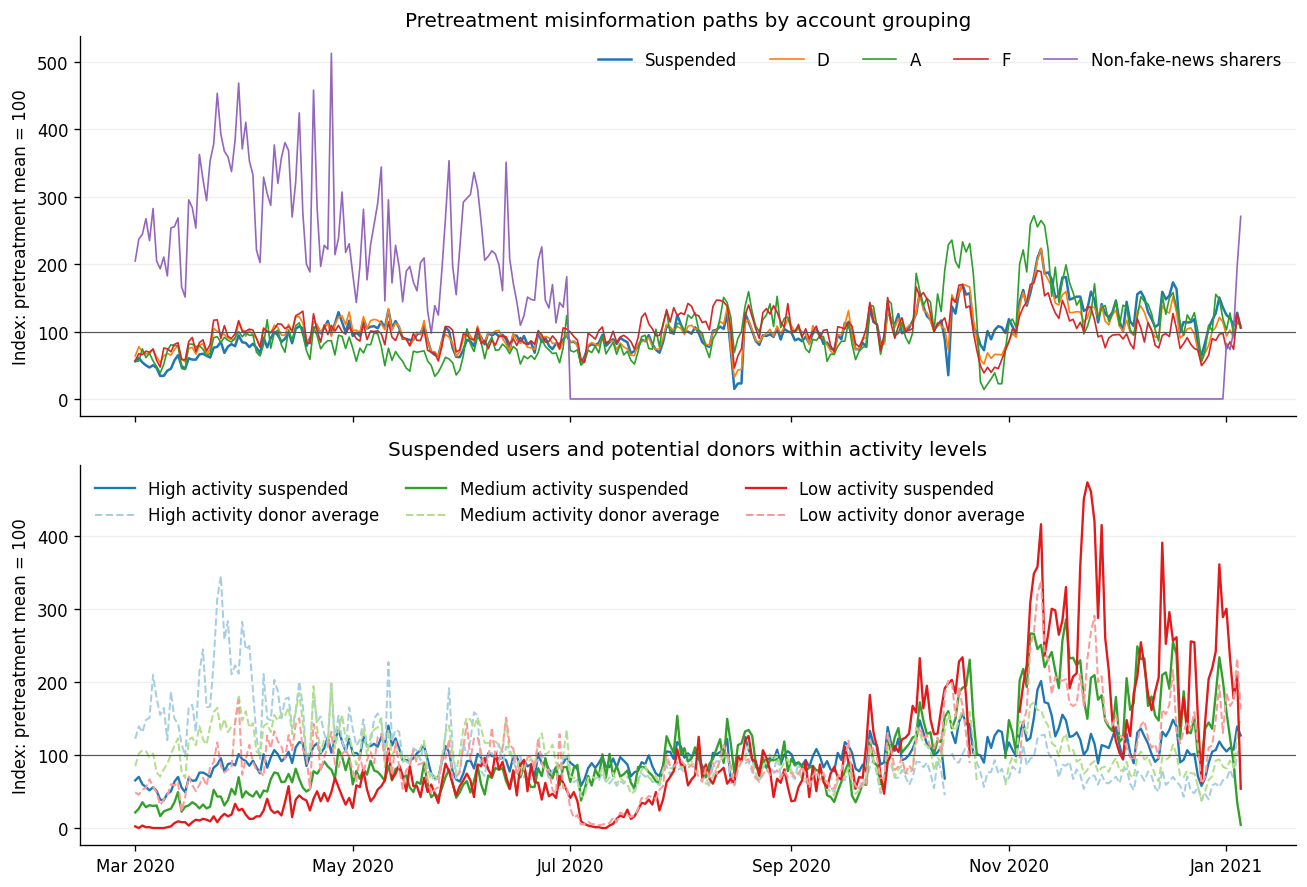

In [6]:
group_series = pd.DataFrame({name: pre_misinformation.loc[pre_misinformation.index >= (pd.Timestamp("2020-03-01"))][columns].sum(axis=1, min_count=1) for name, columns in group_columns.items()})
normalized_groups = group_series.div(group_series.mean()).mul(100)
group_order = ["suspended", "D", "A", "F", "nfns"]
group_labels = {"suspended": "Suspended", "D": "D", "A": "A", "F": "F", "nfns": "Non-fake-news sharers"}
level_labels = {"ha": "High activity", "ma": "Medium activity", "la": "Low activity"}
paired = plt.get_cmap("Paired").colors
level_colors = {"ha": {"suspended": paired[1], "donor": paired[0]}, "ma": {"suspended": paired[3], "donor": paired[2]}, "la": {"suspended": paired[5], "donor": paired[4]}}
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for name in group_order:
    axes[0].plot(normalized_groups[name], linewidth=1.5 if name == "suspended" else 1, label=group_labels[name])
legend_handles = []
legend_labels = []
for level in ["ha", "ma", "la"]:
    level_data = pd.DataFrame({name: pre_misinformation.loc[pre_misinformation.index >= (pd.Timestamp("2020-03-01"))][[column for column in level_columns[level] if column in group_columns[name]]].sum(axis=1, min_count=1) for name in group_columns})
    suspended_path = level_data["suspended"].div(level_data["suspended"].mean()).mul(100)
    donor_path = level_data.drop(columns="suspended").div(level_data.drop(columns="suspended").mean()).mean(axis=1).mul(100)
    suspended_line, = axes[1].plot(suspended_path, color=level_colors[level]["suspended"], linewidth=1.4)
    donor_line, = axes[1].plot(donor_path, color=level_colors[level]["donor"], linewidth=1.2, linestyle="--")
    legend_handles.extend([suspended_line, donor_line])
    legend_labels.extend([f"{level_labels[level]} suspended", f"{level_labels[level]} donor average"])
axes[0].set_title("Pretreatment misinformation paths by account grouping")
axes[1].set_title("Suspended users and potential donors within activity levels")
axes[0].set_ylabel("Index: pretreatment mean = 100")
axes[1].set_ylabel("Index: pretreatment mean = 100")
axes[0].legend(ncol=5, frameon=False)
axes[1].legend(legend_handles, legend_labels, ncol=3, frameon=False, columnspacing=1.6, handlelength=2.4)
for axis in axes:
    axis.axhline(100, linewidth=.7, color="#555555")
    axis.grid(axis="y", alpha=.2)
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "normalized_group_and_donor_paths.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [7]:
rate = pre_misinformation.div(pre_activity.replace(0, np.nan))
relationships = []
for subset in subset_columns:
    data = pd.DataFrame({"misinformation": pre_misinformation[subset], "activity": pre_activity[subset], "users": pre_users[subset], "rate": rate[subset]}).dropna()
    relationships.append({
        "subset": subset,
        "corr_log_misinformation_activity": np.log1p(data["misinformation"]).corr(np.log1p(data["activity"])),
        "corr_log_misinformation_users": np.log1p(data["misinformation"]).corr(np.log1p(data["users"])),
        "corr_rate_activity": data["rate"].corr(np.log1p(data["activity"])),
        "raw_count_cv": data["misinformation"].std() / data["misinformation"].mean(),
        "rate_cv": data["rate"].std() / data["rate"].mean(),
    })
relationship_summary = pd.DataFrame(relationships).merge(subset_metadata, left_on="subset", right_on="subsets").drop(columns="subsets")
relationship_summary.groupby("level")[["corr_log_misinformation_activity", "corr_log_misinformation_users", "corr_rate_activity", "raw_count_cv", "rate_cv"]].mean().round(3)

,corr_log_misinformation_activity,corr_log_misinformation_users,corr_rate_activity,raw_count_cv,rate_cv
level,,,,,
ha,0.628,0.613,-0.277,0.499,0.446
la,0.708,0.691,0.403,1.137,0.703
ma,0.694,0.605,0.129,0.672,0.520


## Time-series behavior

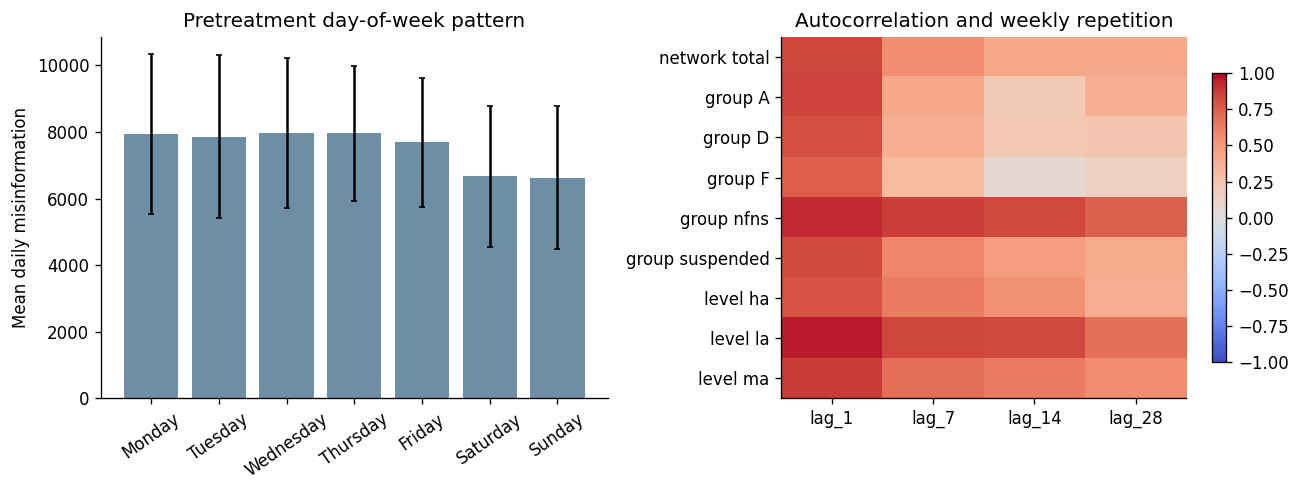

,lag_1,lag_7,lag_14,lag_28
series,,,,
network total,0.838,0.552,0.424,0.428
group A,0.850,0.421,0.198,0.387
group D,0.805,0.392,0.212,0.240
group F,0.752,0.300,0.061,0.144
group nfns,0.925,0.868,0.832,0.745
group suspended,0.821,0.584,0.470,0.403
level ha,0.792,0.631,0.534,0.395
level la,0.956,0.840,0.836,0.680
level ma,0.878,0.694,0.627,0.562


In [8]:
total_pre = pre_misinformation.sum(axis=1, min_count=1)
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = total_pre.groupby(total_pre.index.dayofweek).agg(["mean", "std"])
dow.index = day_names
autocorrelations = []
series_registry = {"network total": total_pre}
series_registry.update({f"group {name}": group_series[name] for name in group_series})
series_registry.update({f"level {name}": pre_misinformation[columns].sum(axis=1, min_count=1) for name, columns in level_columns.items()})
for name, series in series_registry.items():
    autocorrelations.append({"series": name, **{f"lag_{lag}": series.autocorr(lag) for lag in [1, 7, 14, 28]}})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(dow.index, dow["mean"], yerr=dow["std"], color="#547a95", alpha=.85, capsize=2)
axes[0].tick_params(axis="x", rotation=35)
axes[0].set(title="Pretreatment day-of-week pattern", ylabel="Mean daily misinformation")
acf_table = pd.DataFrame(autocorrelations).set_index("series")
image = axes[1].imshow(acf_table, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(acf_table.columns)), acf_table.columns)
axes[1].set_yticks(range(len(acf_table.index)), acf_table.index)
axes[1].set_title("Autocorrelation and weekly repetition")
fig.colorbar(image, ax=axes[1], shrink=.8)
fig.tight_layout()
plt.show()
acf_table.round(3)

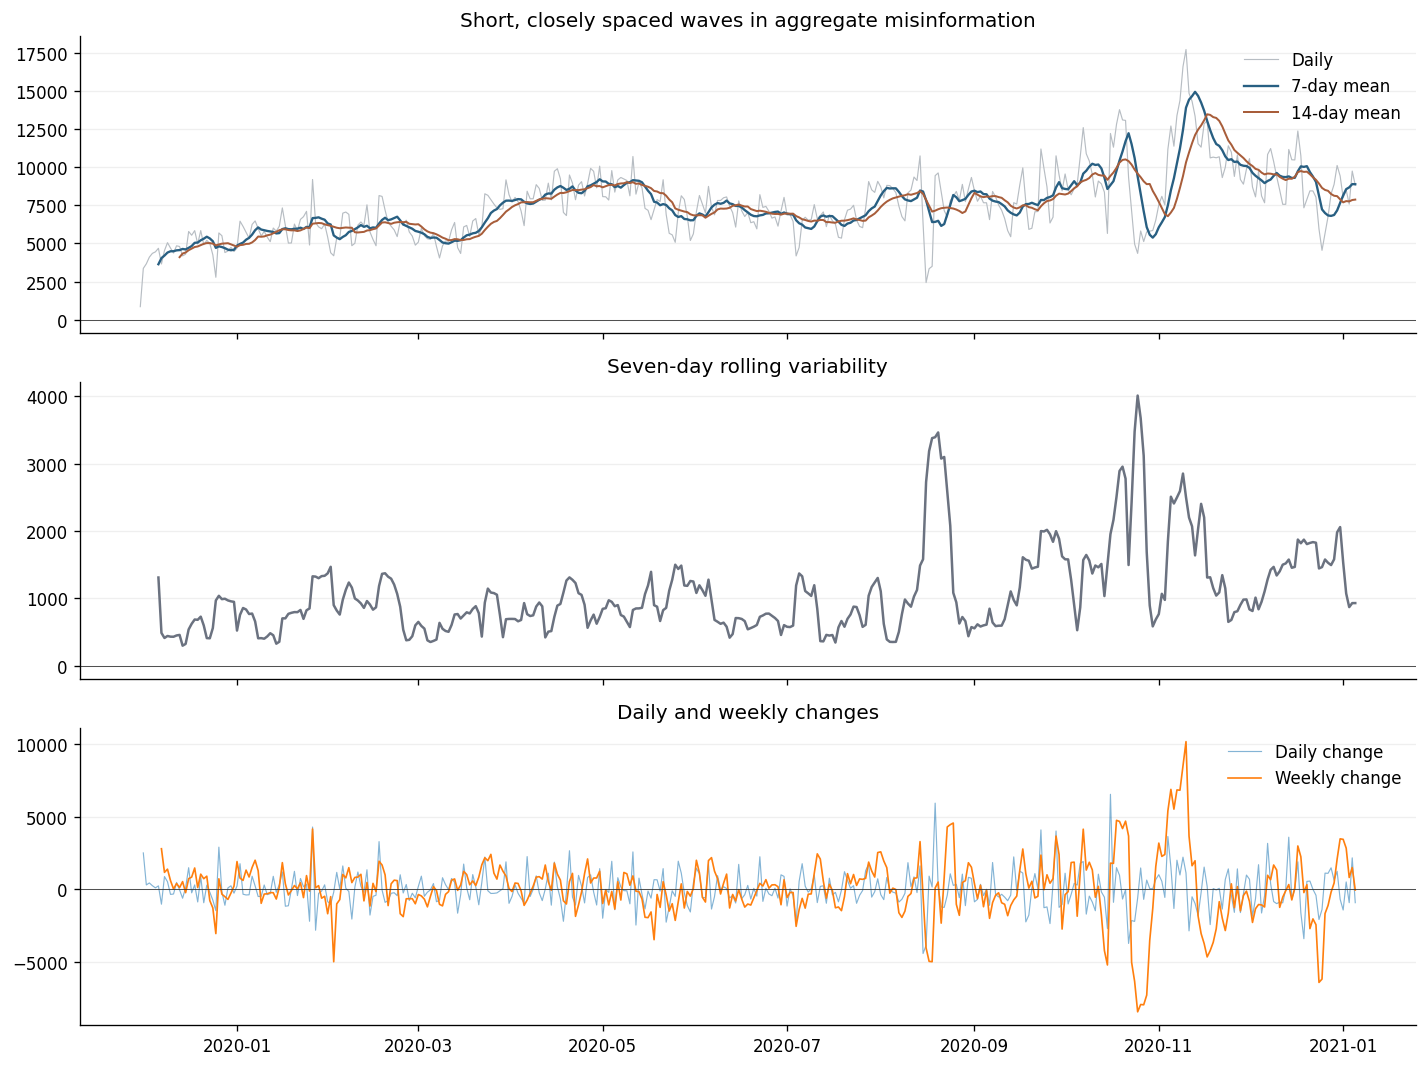

In [9]:
rolling = pd.DataFrame({"daily": total_pre, "mean_7": total_pre.rolling(7).mean(), "mean_14": total_pre.rolling(14).mean(), "sd_7": total_pre.rolling(7).std(), "change_1": total_pre.diff(), "change_7": total_pre.diff(7)})
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(rolling["daily"], color="#b7bdc3", linewidth=.7, label="Daily")
axes[0].plot(rolling["mean_7"], color="#285f82", linewidth=1.4, label="7-day mean")
axes[0].plot(rolling["mean_14"], color="#a85d3a", linewidth=1.2, label="14-day mean")
axes[1].plot(rolling["sd_7"], color="#6b7280")
axes[2].plot(rolling["change_1"], alpha=.55, linewidth=.7, label="Daily change")
axes[2].plot(rolling["change_7"], linewidth=1, label="Weekly change")
axes[0].set_title("Short, closely spaced waves in aggregate misinformation")
axes[1].set_title("Seven-day rolling variability")
axes[2].set_title("Daily and weekly changes")
axes[0].legend(frameon=False)
axes[2].legend(frameon=False)
for axis in axes:
    axis.axhline(0, color="#333333", linewidth=.5)
    axis.grid(axis="y", alpha=.2)
fig.tight_layout()
plt.show()

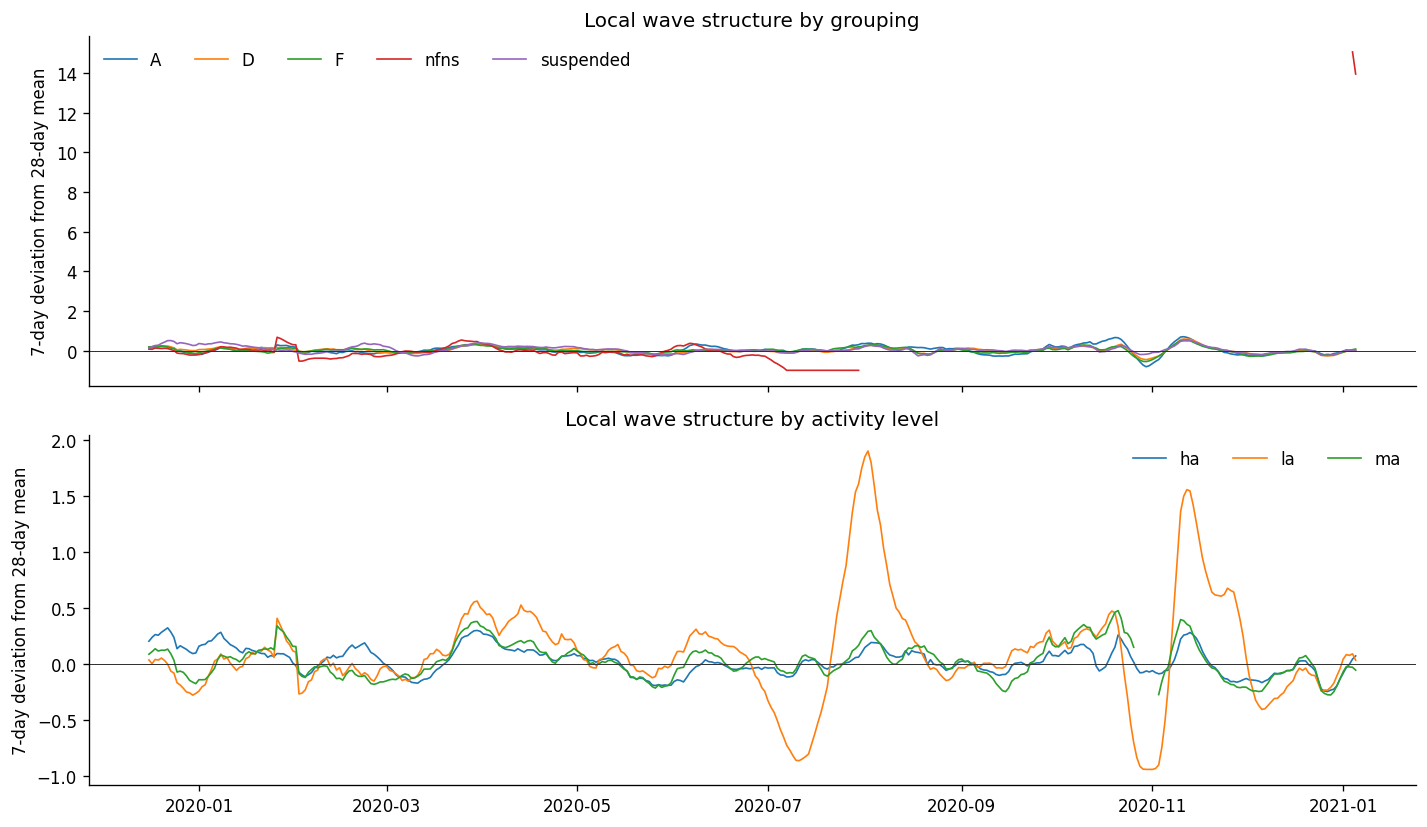

In [49]:
normalized_group_waves = group_series.div(group_series.rolling(28, min_periods=14).mean()).sub(1).rolling(7, min_periods=4).mean()
level_series = pd.DataFrame({name: pre_misinformation[columns].sum(axis=1, min_count=1) for name, columns in level_columns.items()})
normalized_level_waves = level_series.div(level_series.rolling(28, min_periods=14).mean()).sub(1).rolling(7, min_periods=4).mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for name in normalized_group_waves:
    axes[0].plot(normalized_group_waves[name], label=name, linewidth=1)
for name in normalized_level_waves:
    axes[1].plot(normalized_level_waves[name], label=name, linewidth=1)
axes[0].set_title("Local wave structure by grouping")
axes[1].set_title("Local wave structure by activity level")
axes[0].legend(ncol=5, frameon=False)
axes[1].legend(ncol=3, frameon=False)
for axis in axes:
    axis.axhline(0, color="#333333", linewidth=.6)
    axis.set_ylabel("7-day deviation from 28-day mean")
fig.tight_layout()
plt.show()

## Donor comparability

In [12]:
donor_levels = group_series.drop(columns="suspended").corrwith(group_series["suspended"])
donor_changes = group_series.diff(7).drop(columns="suspended").corrwith(group_series["suspended"].diff(7))
comparability = pd.DataFrame({"level_correlation": donor_levels, "weekly_change_correlation": donor_changes})
level_comparability = []
for level, level_subsets in level_columns.items():
    level_data = pd.DataFrame({name: pre_misinformation[list(set(level_subsets).intersection(columns))].sum(axis=1, min_count=1) for name, columns in group_columns.items()})
    for donor in level_data.columns.drop("suspended"):
        level_comparability.append({"level": level, "donor": donor, "level_correlation": level_data["suspended"].corr(level_data[donor]), "weekly_change_correlation": level_data["suspended"].diff(7).corr(level_data[donor].diff(7))})
print("Aggregate grouping relationships")
comparability.round(3)

Aggregate grouping relationships


,level_correlation,weekly_change_correlation
A,0.725,0.591
D,0.913,0.885
F,0.725,0.727
nfns,-0.447,0.081


In [13]:
pd.DataFrame(level_comparability).pivot(index="donor", columns="level", values=["level_correlation", "weekly_change_correlation"]).round(3)

level_correlation               weekly_change_correlation              
level                ha     la     ma                        ha     la     ma
donor                                                                        
A                 0.069  0.879  0.806                     0.327  0.389  0.573
D                 0.781  0.941  0.919                     0.833  0.747  0.725
F                 0.391  0.893  0.528                     0.487  0.650  0.390
nfns             -0.507 -0.406 -0.441                     0.126  0.012  0.050

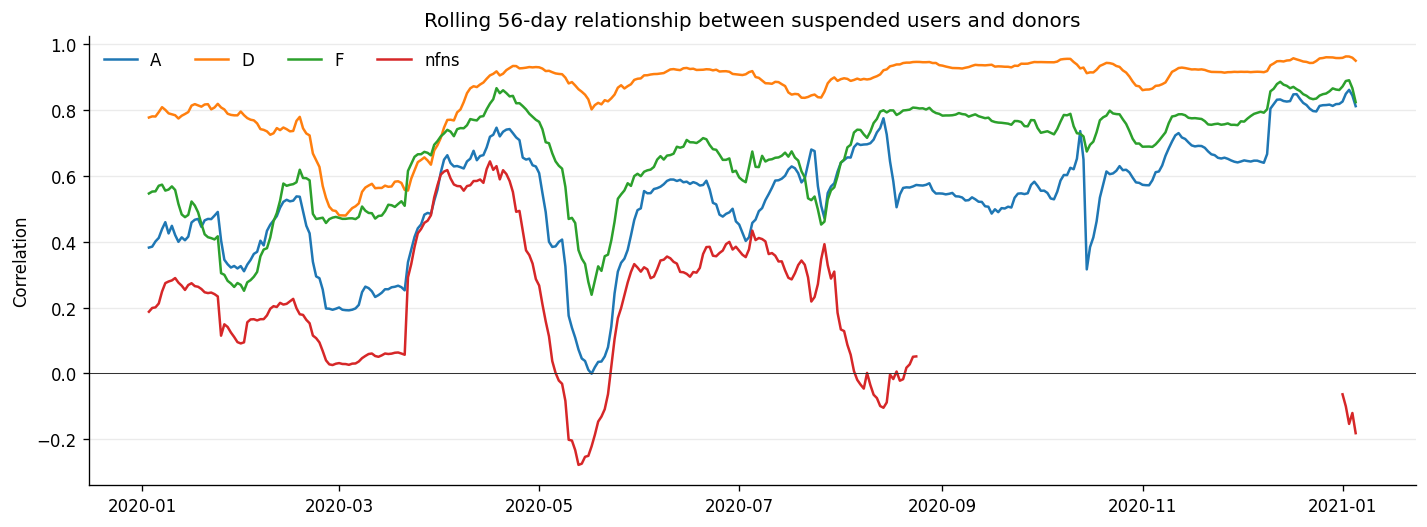

In [14]:
rolling_corr = pd.DataFrame(index=group_series.index)
for donor in group_series.columns.drop("suspended"):
    rolling_corr[donor] = group_series["suspended"].rolling(56, min_periods=35).corr(group_series[donor])
fig, ax = plt.subplots(figsize=(12, 4.5))
for donor in rolling_corr:
    ax.plot(rolling_corr[donor], label=donor)
ax.axhline(0, color="#333333", linewidth=.6)
ax.set(title="Rolling 56-day relationship between suspended users and donors", ylabel="Correlation")
ax.legend(ncol=4, frameon=False)
ax.grid(axis="y", alpha=.25)
fig.tight_layout()
plt.show()

# GDELT features

In [15]:
def logit(values):
    clipped = np.clip(values, 1e-5, 1 - 1e-5)
    return np.log(clipped / (1 - clipped))

def gdelt_blocks(election, events, index):
    election = election.set_index("date").reindex(index)
    events = events.set_index("date").reindex(index)
    election = election[[column for column in election if "election_platform" not in column]]
    events = events.drop(columns=[column for column in events if "_root_event_count" in column])
    election_attention = [column for column in election if column.startswith("us_") or column.startswith("election_")]
    political_actors = [column for column in election if column not in election_attention]
    environment_names = {"verbal_conflict_share", "material_conflict_share", "contentious_event_count", "contentious_event_share", "contentious_mention_weighted_goldstein", "violence_event_count", "violence_event_share", "violence_mention_weighted_goldstein"}
    event_environment = [column for column in events if column.startswith("us_") or column in environment_names]
    event_categories = [column for column in events if column not in event_environment]
    return {"election attention": election[election_attention], "political actors": election[political_actors], "event environment": events[event_environment], "event categories": events[event_categories]}

def transform_gdelt(frame):
    transformed = frame.astype(float).copy()
    for column in transformed:
        if column.endswith("_share") or column in {"us_negative_share", "us_positive_share", "verbal_conflict_share", "material_conflict_share"}:
            transformed[column] = logit(transformed[column].clip(1e-6, 1 - 1e-6))
        elif any(token in column for token in ["_count", "_mentions", "_articles", "_source_count", "_source_mentions", "_document_count"]):
            transformed[column] = np.log1p(transformed[column].clip(lower=0))
    return transformed

gdelt_feature_blocks = gdelt_blocks(gdelt_election, gdelt_events, model_dates)
block_coverage = []
for name, block in gdelt_feature_blocks.items():
    block_coverage.append({"block": name, "features": block.shape[1], "missing_values": int(block.isna().sum().sum()), "features_with_missing": int(block.isna().any().sum()), "median_nonmissing_days": int(block.notna().sum().median())})
pd.DataFrame(block_coverage)

,block,features,missing_values,features_with_missing,median_nonmissing_days
0,election attention,36,853,2,528
1,political actors,24,0,0,528
2,event environment,16,0,0,528
3,event categories,27,48,1,528


In [16]:
distribution_rows = []
redundancy_rows = []
pca_scores = {}
pca_artifacts = {}
for name, block in gdelt_feature_blocks.items():
    transformed = transform_gdelt(block)
    eligible = [column for column in transformed if transformed.loc[:PRETREATMENT_END, column].notna().sum() >= 30 and transformed.loc[:PRETREATMENT_END, column].nunique(dropna=True) > 1]
    transformed = transformed[eligible]
    pre = transformed.loc[:PRETREATMENT_END]
    raw_pre = block.loc[:PRETREATMENT_END, eligible]
    distribution_rows.append({"block": name, "raw_median_absolute": raw_pre.abs().median().median(), "raw_95th_absolute": raw_pre.abs().quantile(.95).median(), "transformed_median_absolute": pre.abs().median().median(), "transformed_95th_absolute": pre.abs().quantile(.95).median()})
    correlations = pre.corr().abs()
    upper = correlations.where(np.triu(np.ones(correlations.shape), 1).astype(bool)).stack()
    redundancy_rows.append({"block": name, "features": len(eligible), "pairs_above_0.90": int(upper.gt(.9).sum()), "maximum_absolute_correlation": upper.max()})
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    pre_scaled = scaler.fit_transform(imputer.fit_transform(pre))
    components = min(GDELT_COMPONENTS, pre_scaled.shape[1], pre_scaled.shape[0] - 1)
    pca = PCA(n_components=components, random_state=SEED).fit(pre_scaled)
    all_scores = pca.transform(scaler.transform(imputer.transform(transformed)))
    pca_scores[name] = pd.DataFrame(all_scores, index=model_dates, columns=[f"PC{number}" for number in range(1, components + 1)])
    pca_artifacts[name] = {"variance": pca.explained_variance_ratio_, "columns": eligible}
print("Raw and transformed scale")
pd.DataFrame(distribution_rows).round(3)

Raw and transformed scale


,block,raw_median_absolute,raw_95th_absolute,transformed_median_absolute,transformed_95th_absolute
0,election attention,2.993,3.855,3.046,3.914
1,political actors,1.847,3.064,3.727,4.767
2,event environment,4.802,5.307,5.058,5.415
3,event categories,3.301,4.916,4.272,5.080


In [17]:
pd.DataFrame(redundancy_rows).round(3)

,block,features,pairs_above_0.90,maximum_absolute_correlation
0,election attention,36,54,0.994
1,political actors,24,8,0.971
2,event environment,16,20,1.000
3,event categories,27,13,0.969


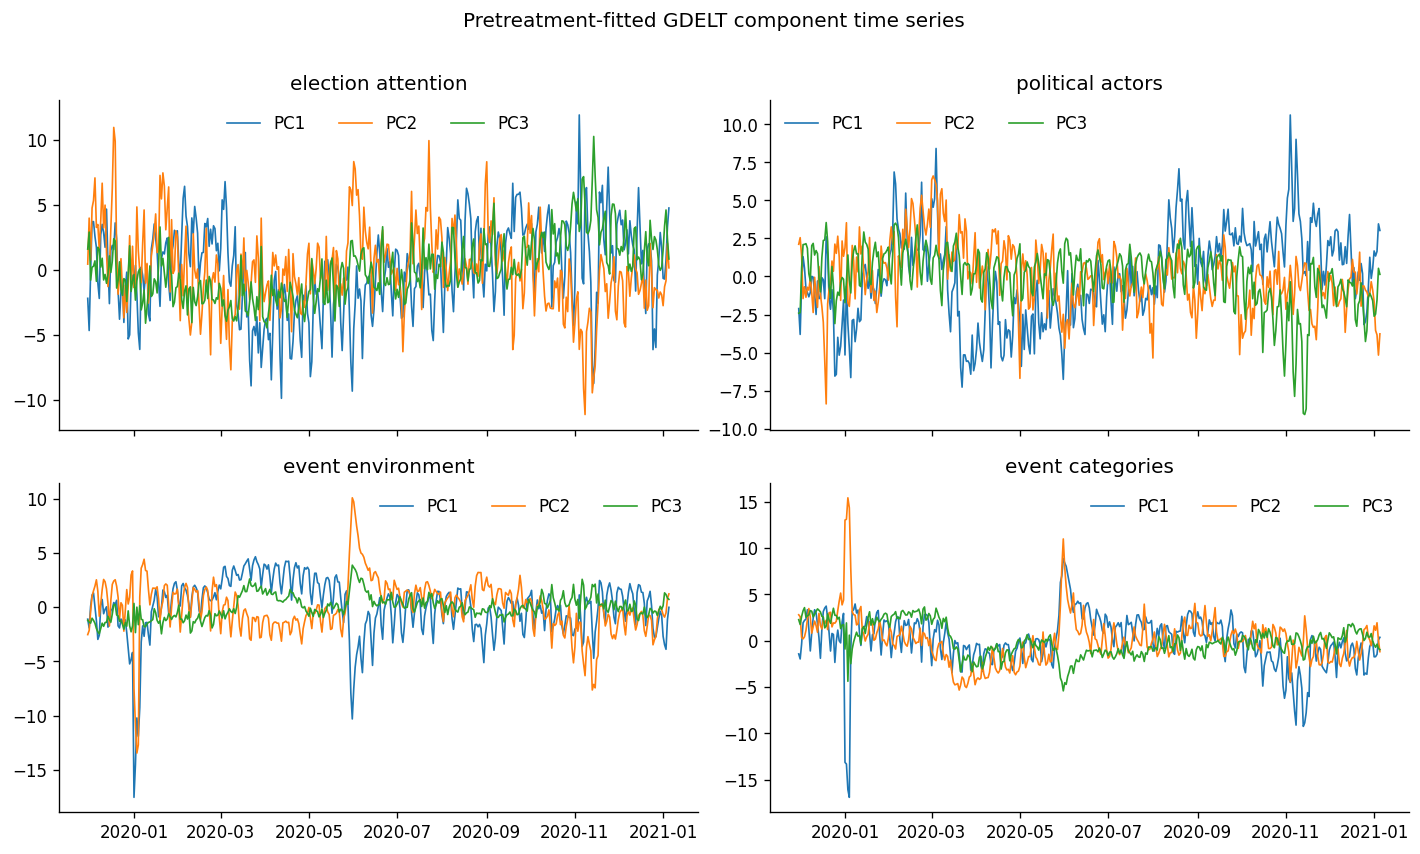

,election attention,political actors,event environment,event categories
PC1,0.328,0.374,0.443,0.308
PC2,0.265,0.191,0.384,0.249
PC3,0.150,0.146,0.071,0.112


In [18]:
variance = pd.DataFrame({name: artifact["variance"] for name, artifact in pca_artifacts.items()}, index=["PC1", "PC2", "PC3"])
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for axis, (name, scores) in zip(axes.flat, pca_scores.items()):
    for component in scores:
        axis.plot(scores.loc[:PRETREATMENT_END, component], label=component, linewidth=1)
    axis.set_title(name)
    axis.legend(frameon=False, ncol=3)
fig.suptitle("Pretreatment-fitted GDELT component time series", y=1.01)
fig.tight_layout()
plt.show()
variance.round(3)

In [19]:
lag_rows = []
for block, scores in pca_scores.items():
    for component in scores:
        lagged = pd.concat({f"lag_{lag}": scores[component].shift(lag) for lag in [1, 3, 7]}, axis=1).loc[:PRETREATMENT_END]
        lag_rows.append({
            "block": block,
            "component": component,
            "corr_lag1_lag3": lagged["lag_1"].corr(lagged["lag_3"]),
            "corr_lag1_lag7": lagged["lag_1"].corr(lagged["lag_7"]),
            "misinfo_corr_lag1": total_pre.corr(lagged["lag_1"]),
            "misinfo_corr_lag3": total_pre.corr(lagged["lag_3"]),
            "misinfo_corr_lag7": total_pre.corr(lagged["lag_7"]),
        })
lag_diagnostics = pd.DataFrame(lag_rows)
lag_diagnostics.round(3)

,block,component,corr_lag1_lag3,corr_lag1_lag7,misinfo_corr_lag1,misinfo_corr_lag3,misinfo_corr_lag7
0,election attention,PC1,0.452,0.541,0.110,-0.021,0.187
1,election attention,PC2,0.465,0.352,-0.266,-0.309,-0.219
2,election attention,PC3,0.611,0.671,0.375,0.471,0.294
3,political actors,PC1,0.729,0.634,0.274,0.220,0.279
4,political actors,PC2,0.538,0.404,-0.225,-0.241,-0.227
5,political actors,PC3,0.470,0.558,-0.370,-0.496,-0.267
6,event environment,PC1,0.647,0.567,0.070,-0.032,0.130
7,event environment,PC2,0.599,0.386,-0.279,-0.331,-0.185
8,event environment,PC3,0.759,0.646,0.276,0.329,0.311
9,event categories,PC1,0.572,0.387,-0.314,-0.374,-0.216
